# Pose estimation para bovinos

Este notebook consolida a implementação completa do trabalho com foco em bovinos a partir do **ANIMAL-POSE DATASET**.

O fluxo está organizado em quatro partes:

1. análise exploratória do dataset;
2. filtragem e processamento das imagens de bovinos;
3. treinamento e avaliação de um baseline de pose estimation com **MobileNetV3-Small**;
4. conclusões finais sobre aprendizados, limitações e próximos passos.

In [1]:
from __future__ import annotations

import copy
import json
import os
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.patches import FancyArrowPatch, Rectangle
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import MobileNet_V3_Small_Weights, mobilenet_v3_small

plt.style.use("seaborn-v0_8-whitegrid")

REPO_ROOT = Path('.').resolve()
KEYPOINTS_JSON = REPO_ROOT / 'keypoints.json'
DATASET_DIR = REPO_ROOT / 'animalpose_image_part2'
COW_IMAGE_DIR = DATASET_DIR / 'cow'
FIG_DIR = REPO_ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

os.environ.setdefault('TORCH_HOME', str(REPO_ROOT / '.torch_cache'))

TARGET_SIZE = 256
PAD_RATIO = 0.10
EXAMPLE_FILENAME = 'co1.jpeg'
SEED = 42
EPOCHS = 12
BATCH_SIZE = 16
LEARNING_RATE = 1e-3

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 1. Preparação dos dados e visão geral

As próximas células carregam o JSON anotado, contam as amostras por espécie e isolam o subconjunto bovino realmente disponível no repositório local.

In [2]:
def load_animal_pose(path: Path) -> dict:
    with path.open(encoding='utf-8') as f:
        return json.load(f)


def get_local_file_counts(dataset_dir: Path) -> dict[str, int]:
    counts = {}
    for subdir in sorted(dataset_dir.iterdir()):
        if subdir.is_dir():
            counts[subdir.name] = sum(1 for p in subdir.iterdir() if p.is_file())
    return counts


def compute_species_stats(data: dict) -> dict[str, dict[str, int]]:
    categories = {c['id']: c['name'] for c in data['categories']}
    ann_counts = Counter()
    unique_images = defaultdict(set)
    for ann in data['annotations']:
        cid = ann['category_id']
        ann_counts[cid] += 1
        unique_images[cid].add(ann['image_id'])
    stats = {}
    for cid in sorted(categories):
        name = categories[cid]
        stats[name] = {
            'annotations': ann_counts[cid],
            'images': len(unique_images[cid]),
        }
    return stats


def filter_cow_annotations_on_disk(data: dict, cow_dir: Path) -> tuple[list[dict], dict[int, str], set[str]]:
    images_map = {int(k): v for k, v in data['images'].items()}
    on_disk = {p.name for p in cow_dir.iterdir() if p.is_file()}
    cow_anns = []
    for ann in data['annotations']:
        if ann['category_id'] != 5:
            continue
        filename = images_map.get(int(ann['image_id']))
        if filename in on_disk:
            cow_anns.append(ann)
    cow_anns.sort(key=lambda ann: images_map[int(ann['image_id'])])
    return cow_anns, images_map, on_disk


def save_current_figure(path: Path):
    plt.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close()


def draw_pose(ax, img_arr: np.ndarray, keypoints: list[list[float]] | np.ndarray, skeleton_edges: list[tuple[int, int]], *,
              point_color='yellow', edge_color='#0b4f6c', edge_alpha=0.9, linewidth=2.0):
    ax.imshow(img_arr)
    pts = np.asarray(keypoints, dtype=float)
    for i, j in skeleton_edges:
        p1 = pts[i]
        p2 = pts[j]
        if p1[2] > 0 and p2[2] > 0:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color=edge_color, linewidth=linewidth, alpha=edge_alpha)
    vis = pts[:, 2] > 0
    if vis.any():
        ax.scatter(pts[vis, 0], pts[vis, 1], s=28, c=point_color, edgecolors='black', linewidths=0.5, zorder=5)
    ax.axis('off')


def padded_bbox_crop(image: Image.Image, bbox: list[float], pad_ratio: float = PAD_RATIO):
    x, y, w, h = bbox
    pad = int(round(max(w, h) * pad_ratio))
    x0 = max(int(np.floor(x - pad)), 0)
    y0 = max(int(np.floor(y - pad)), 0)
    x1 = min(int(np.ceil(x + w + pad)), image.width)
    y1 = min(int(np.ceil(y + h + pad)), image.height)
    crop = image.crop((x0, y0, x1, y1))
    return crop, (x0, y0, x1, y1)


def square_pad(image: Image.Image, fill=(255, 255, 255)):
    side = max(image.width, image.height)
    square = Image.new('RGB', (side, side), fill)
    offset_x = (side - image.width) // 2
    offset_y = (side - image.height) // 2
    square.paste(image, (offset_x, offset_y))
    return square, offset_x, offset_y


def preprocess_annotation(image: Image.Image, ann: dict, target_size: int = TARGET_SIZE, pad_ratio: float = PAD_RATIO):
    crop, crop_box = padded_bbox_crop(image, ann['bbox'], pad_ratio=pad_ratio)
    square, offset_x, offset_y = square_pad(crop)
    resized = square.resize((target_size, target_size), Image.Resampling.BILINEAR)
    scale = target_size / square.width
    transformed = []
    normalized = []
    visibility_mask = []
    for x, y, v in ann['keypoints']:
        visibility_mask.append(float(v > 0))
        if v <= 0:
            transformed.append([0.0, 0.0, v])
            normalized.append([0.0, 0.0])
            continue
        cx = (x - crop_box[0]) + offset_x
        cy = (y - crop_box[1]) + offset_y
        tx = cx * scale
        ty = cy * scale
        transformed.append([tx, ty, v])
        normalized.append([tx / target_size, ty / target_size])
    return {
        'crop': crop,
        'crop_box': crop_box,
        'square': square,
        'offset_x': offset_x,
        'offset_y': offset_y,
        'scale': scale,
        'resized': resized,
        'transformed_keypoints': transformed,
        'normalized_keypoints': normalized,
        'visibility_mask': visibility_mask,
    }


def select_device() -> torch.device:
    if torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


class CowPoseDataset(Dataset):
    def __init__(self, annotations: list[dict], images_map: dict[int, str], image_dir: Path):
        self.annotations = annotations
        self.images_map = images_map
        self.image_dir = image_dir
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])

    def __len__(self) -> int:
        return len(self.annotations)

    def __getitem__(self, idx: int) -> dict:
        ann = self.annotations[idx]
        filename = self.images_map[int(ann['image_id'])]
        image = Image.open(self.image_dir / filename).convert('RGB')
        processed = preprocess_annotation(image, ann)
        return {
            'image': self.transform(processed['resized']),
            'target': torch.tensor(processed['normalized_keypoints'], dtype=torch.float32),
            'visibility': torch.tensor(processed['visibility_mask'], dtype=torch.float32),
            'filename': filename,
        }


def collate_pose_batch(batch: list[dict]) -> dict:
    return {
        'image': torch.stack([item['image'] for item in batch]),
        'target': torch.stack([item['target'] for item in batch]),
        'visibility': torch.stack([item['visibility'] for item in batch]),
        'filename': [item['filename'] for item in batch],
    }


def masked_smooth_l1(predictions: torch.Tensor, targets: torch.Tensor, visibility: torch.Tensor) -> torch.Tensor:
    mask = visibility.unsqueeze(-1)
    loss = nn.functional.smooth_l1_loss(predictions, targets, reduction='none')
    masked_loss = loss * mask
    denominator = (mask.sum() * predictions.shape[-1]).clamp_min(1.0)
    return masked_loss.sum() / denominator


def make_train_val_split(annotations: list[dict], seed: int = SEED, val_ratio: float = 0.20):
    indices = list(range(len(annotations)))
    rng = random.Random(seed)
    rng.shuffle(indices)
    val_size = max(1, int(round(len(indices) * val_ratio)))
    val_indices = set(indices[:val_size])
    train_annotations = [annotations[i] for i in range(len(annotations)) if i not in val_indices]
    val_annotations = [annotations[i] for i in range(len(annotations)) if i in val_indices]
    return train_annotations, val_annotations


def load_pose_model(device: torch.device):
    try:
        model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.DEFAULT)
        pretrained_loaded = True
    except Exception as exc:
        print(f'Nao foi possivel carregar pesos pre-treinados: {exc}')
        model = mobilenet_v3_small(weights=None)
        pretrained_loaded = False

    if pretrained_loaded:
        for param in model.features.parameters():
            param.requires_grad = False
        for param in model.features[-1].parameters():
            param.requires_grad = True

    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(0.2),
        nn.Linear(256, 40),
        nn.Sigmoid(),
    )
    return model.to(device), pretrained_loaded


def evaluate_pose_model(model: nn.Module, dataloader: DataLoader, device: torch.device) -> dict:
    model.eval()
    batch_losses = []
    predictions_list = []
    targets_list = []
    visibility_list = []

    with torch.no_grad():
        for batch in dataloader:
            images = batch['image'].to(device)
            targets = batch['target'].to(device)
            visibility = batch['visibility'].to(device)
            predictions = model(images).view(-1, 20, 2)
            loss = masked_smooth_l1(predictions, targets, visibility)
            batch_losses.append(loss.item())
            predictions_list.append(predictions.cpu())
            targets_list.append(targets.cpu())
            visibility_list.append(visibility.cpu())

    predictions = torch.cat(predictions_list)
    targets = torch.cat(targets_list)
    visibility = torch.cat(visibility_list)
    coord_mask = visibility.unsqueeze(-1).bool().expand_as(predictions)

    mae_normalized = (predictions[coord_mask] - targets[coord_mask]).abs().mean().item()
    mae_pixels = mae_normalized * TARGET_SIZE
    distances = torch.sqrt(((predictions - targets) ** 2).sum(dim=-1))
    valid_points = visibility > 0
    pck_005 = (distances[valid_points] <= 0.05).float().mean().item()
    pck_010 = (distances[valid_points] <= 0.10).float().mean().item()

    per_keypoint_px_error = []
    per_keypoint_counts = []
    for keypoint_index in range(predictions.shape[1]):
        mask = valid_points[:, keypoint_index]
        per_keypoint_counts.append(int(mask.sum().item()))
        if mask.any():
            per_keypoint_px_error.append(float((distances[mask, keypoint_index].mean().item()) * TARGET_SIZE))
        else:
            per_keypoint_px_error.append(float('nan'))

    return {
        'loss': float(np.mean(batch_losses)),
        'mae_normalized': float(mae_normalized),
        'mae_pixels': float(mae_pixels),
        'pck_005': float(pck_005),
        'pck_010': float(pck_010),
        'per_keypoint_px_error': per_keypoint_px_error,
        'per_keypoint_counts': per_keypoint_counts,
        'visible_keypoints': int(valid_points.sum().item()),
    }


def predict_annotation(model: nn.Module, ann: dict, images_map: dict[int, str], image_dir: Path, device: torch.device) -> dict:
    filename = images_map[int(ann['image_id'])]
    image = Image.open(image_dir / filename).convert('RGB')
    processed = preprocess_annotation(image, ann)
    image_tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ])(processed['resized']).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = model(image_tensor).view(20, 2).cpu().numpy()

    predicted_keypoints = []
    ground_truth = []
    for (px, py), (tx, ty, v) in zip(pred, processed['transformed_keypoints']):
        predicted_keypoints.append([float(px * TARGET_SIZE), float(py * TARGET_SIZE), float(v)])
        ground_truth.append([float(tx), float(ty), float(v)])

    return {
        'filename': filename,
        'image': np.array(processed['resized']),
        'predicted_keypoints': predicted_keypoints,
        'ground_truth_keypoints': ground_truth,
    }


data = load_animal_pose(KEYPOINTS_JSON)
species_stats = compute_species_stats(data)
local_counts = get_local_file_counts(DATASET_DIR)
cow_anns, images_map, cow_files_on_disk = filter_cow_annotations_on_disk(data, COW_IMAGE_DIR)
categories = {c['id']: c for c in data['categories']}
cow_cat = categories[5]
kp_names = cow_cat['keypoints']
skeleton = [tuple(edge) for edge in cow_cat['skeleton']]
device = select_device()

print(f'Imagens referenciadas no JSON: {len(data["images"])}')
print(f'Anotacoes totais: {len(data["annotations"])}')
print(f'Imagens unicas de bovinos no JSON: {species_stats["cow"]["images"]}')
print(f'Anotacoes de bovinos no JSON: {species_stats["cow"]["annotations"]}')
print(f'Imagens locais disponiveis no repositorio: {sum(local_counts.values())}')
print(f'Arquivos em cow/: {local_counts["cow"]}')
print(f'Anotacoes bovinas efetivamente processadas: {len(cow_anns)}')
print(f'Device selecionado para treinamento: {device}')

Imagens referenciadas no JSON: 4608
Anotacoes totais: 6117
Imagens unicas de bovinos no JSON: 534
Anotacoes de bovinos no JSON: 842
Imagens locais disponiveis no repositorio: 1000
Arquivos em cow/: 200
Anotacoes bovinas efetivamente processadas: 200
Device selecionado para treinamento: mps


## 1.1 Distribuição do dataset

Os gráficos abaixo mostram duas perspectivas complementares do conjunto completo anotado: quantidade de anotações e quantidade de imagens únicas por espécie.

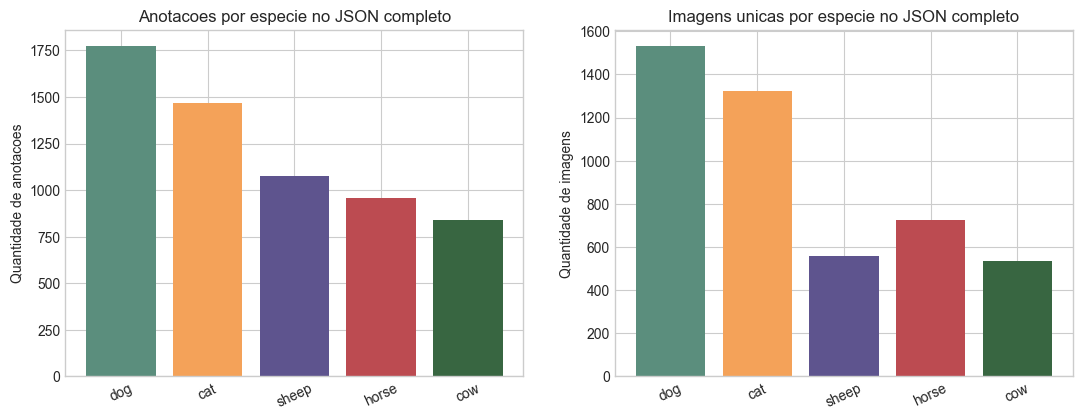

In [3]:
species = list(species_stats.keys())
ann_values = [species_stats[name]['annotations'] for name in species]
img_values = [species_stats[name]['images'] for name in species]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(species, ann_values, color=['#5b8e7d', '#f4a259', '#5e548e', '#bc4b51', '#386641'])
axes[0].set_title('Anotacoes por especie no JSON completo')
axes[0].set_ylabel('Quantidade de anotacoes')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(species, img_values, color=['#5b8e7d', '#f4a259', '#5e548e', '#bc4b51', '#386641'])
axes[1].set_title('Imagens unicas por especie no JSON completo')
axes[1].set_ylabel('Quantidade de imagens')
axes[1].tick_params(axis='x', rotation=25)

save_current_figure(FIG_DIR / '01_species_distribution.png')

## 1.2 Subconjunto de bovinos usado no projeto

Como o repositório local contém apenas parte das imagens do dataset, o processamento prático considera a interseção entre o `keypoints.json` e os arquivos realmente presentes em `animalpose_image_part2/cow/`.

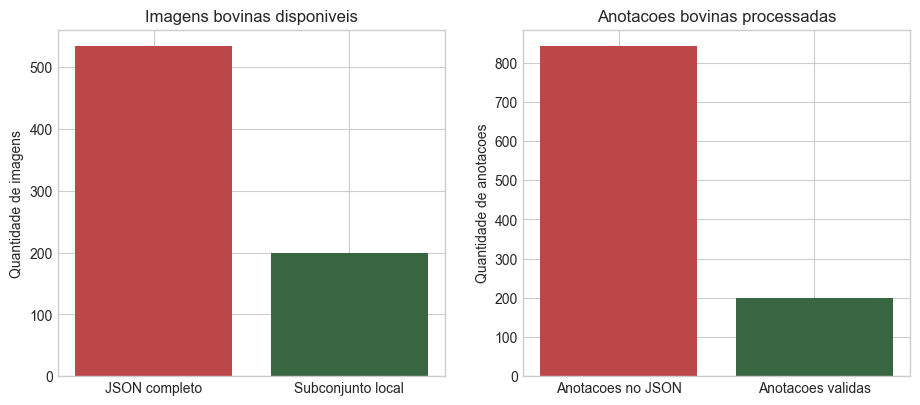

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(['JSON completo', 'Subconjunto local'], [species_stats['cow']['images'], local_counts['cow']], color=['#bc4749', '#386641'])
axes[0].set_title('Imagens bovinas disponiveis')
axes[0].set_ylabel('Quantidade de imagens')

axes[1].bar(['Anotacoes no JSON', 'Anotacoes validas'], [species_stats['cow']['annotations'], len(cow_anns)], color=['#bc4749', '#386641'])
axes[1].set_title('Anotacoes bovinas processadas')
axes[1].set_ylabel('Quantidade de anotacoes')

save_current_figure(FIG_DIR / '02_bovine_subset_comparison.png')

## 1.3 Qualidade estrutural das anotações bovinas

Nesta etapa observamos a visibilidade dos keypoints, o tamanho das bounding boxes e as dimensões reais das imagens bovinas disponíveis localmente.

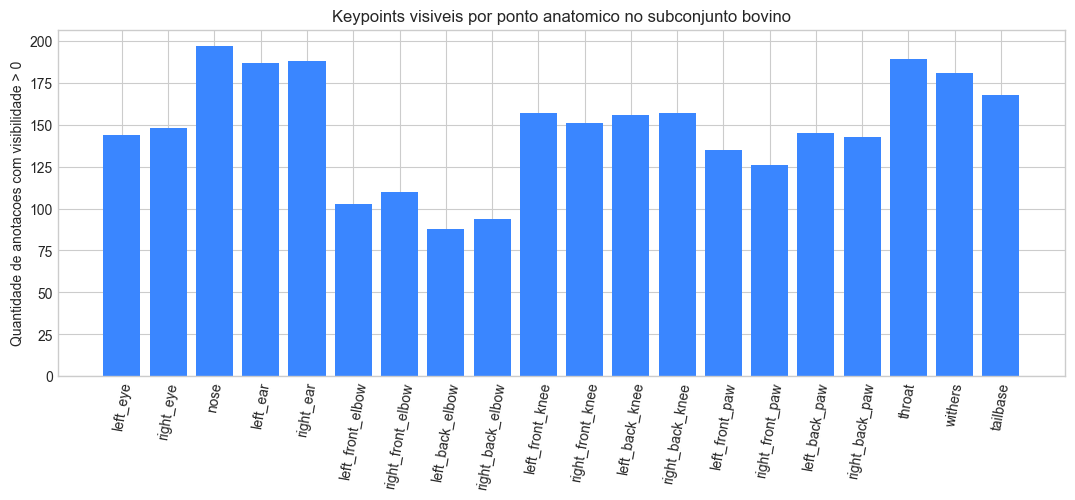

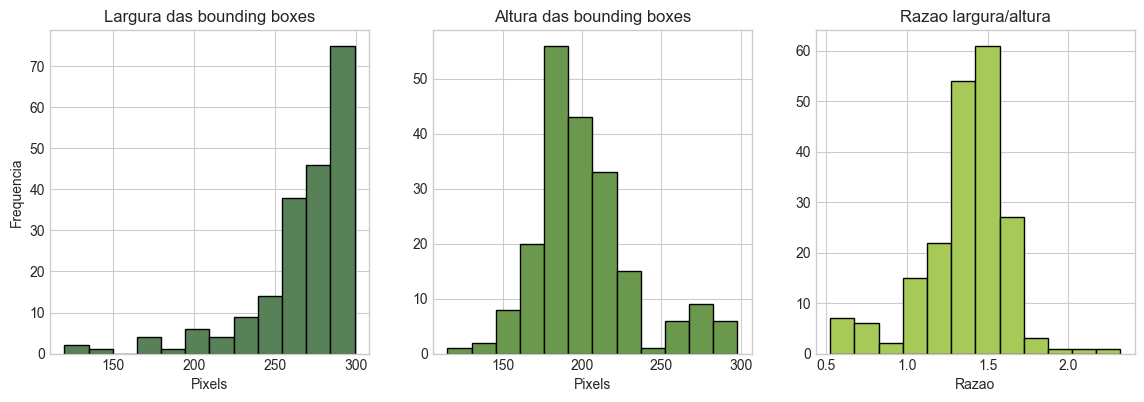

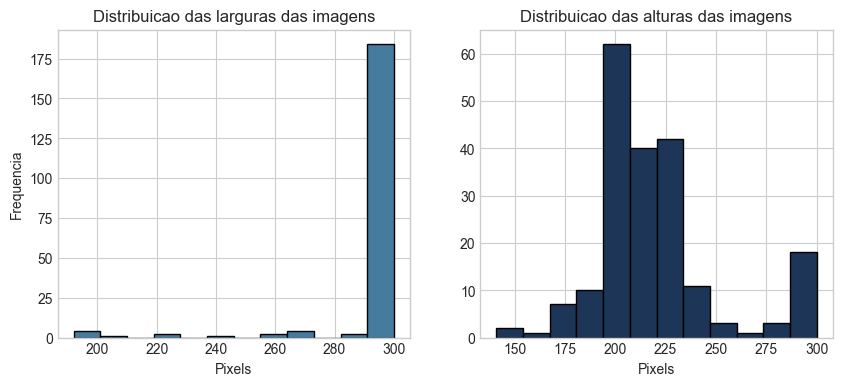

In [5]:
visible_per_kp = np.zeros(len(kp_names), dtype=int)
bbox_widths, bbox_heights, aspect_ratios = [], [], []
image_widths, image_heights = [], []

for ann in cow_anns:
    for idx, (_, _, v) in enumerate(ann['keypoints']):
        if v > 0:
            visible_per_kp[idx] += 1
    _, _, w, h = ann['bbox']
    bbox_widths.append(w)
    bbox_heights.append(h)
    aspect_ratios.append(w / h)

    filename = images_map[int(ann['image_id'])]
    with Image.open(COW_IMAGE_DIR / filename) as img:
        image_widths.append(img.width)
        image_heights.append(img.height)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(kp_names, visible_per_kp, color='#3a86ff')
ax.set_title('Keypoints visiveis por ponto anatomico no subconjunto bovino')
ax.set_ylabel('Quantidade de anotacoes com visibilidade > 0')
ax.tick_params(axis='x', rotation=80)
save_current_figure(FIG_DIR / '03_keypoint_visibility.png')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
axes[0].hist(bbox_widths, bins=12, color='#588157', edgecolor='black')
axes[0].set_title('Largura das bounding boxes')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Frequencia')

axes[1].hist(bbox_heights, bins=12, color='#6a994e', edgecolor='black')
axes[1].set_title('Altura das bounding boxes')
axes[1].set_xlabel('Pixels')

axes[2].hist(aspect_ratios, bins=12, color='#a7c957', edgecolor='black')
axes[2].set_title('Razao largura/altura')
axes[2].set_xlabel('Razao')

save_current_figure(FIG_DIR / '04_bbox_statistics.png')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(image_widths, bins=12, color='#457b9d', edgecolor='black')
axes[0].set_title('Distribuicao das larguras das imagens')
axes[0].set_xlabel('Pixels')
axes[0].set_ylabel('Frequencia')

axes[1].hist(image_heights, bins=12, color='#1d3557', edgecolor='black')
axes[1].set_title('Distribuicao das alturas das imagens')
axes[1].set_xlabel('Pixels')

save_current_figure(FIG_DIR / '05_image_dimensions.png')

## 1.4 Amostra visual das poses anotadas

A visualização abaixo ajuda a validar rapidamente se as anotações acompanham corretamente a estrutura corporal dos bovinos presentes no subconjunto local.

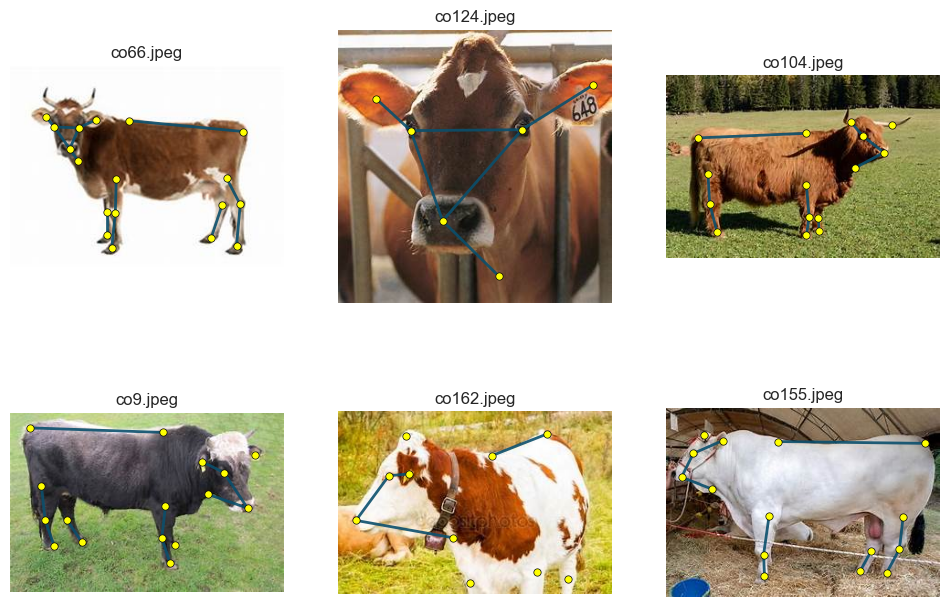

In [6]:
sample_anns = random.Random(SEED).sample(cow_anns, k=6)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, ann in zip(axes.flat, sample_anns):
    filename = images_map[int(ann['image_id'])]
    img_arr = np.array(Image.open(COW_IMAGE_DIR / filename).convert('RGB'))
    draw_pose(ax, img_arr, ann['keypoints'], skeleton)
    ax.set_title(filename)

save_current_figure(FIG_DIR / '06_cow_pose_samples.png')

## 2. Filtragem para bovinos e pipeline de processamento

A partir deste ponto, todas as operações consideram apenas amostras bovinas válidas no disco. O pipeline faz filtragem por classe, interseção com arquivos locais, recorte pela `bbox`, margem de contexto, padding quadrado, resize para `256x256` e remapeamento dos keypoints.

## 2.1 Figura ilustrativa do pipeline

A figura a seguir resume o fluxo de pré-processamento usado antes do treinamento do baseline.

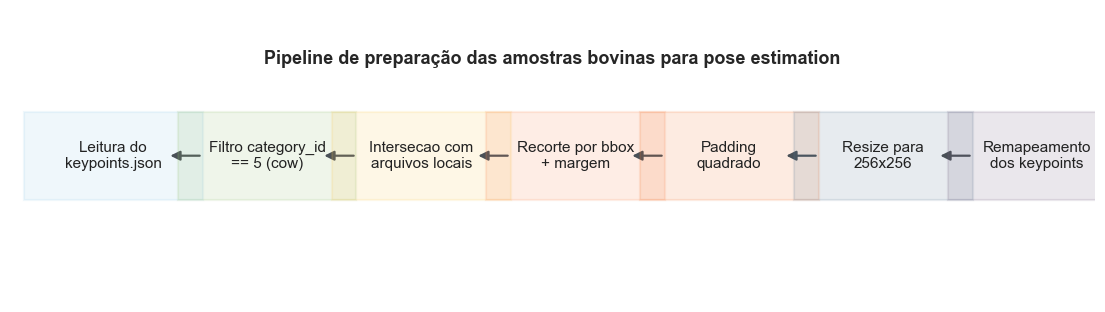

In [7]:
def add_pipeline_box(ax, xy, text, color):
    x, y = xy
    rect = Rectangle((x, y), 2.55, 0.9, linewidth=1.6, edgecolor=color, facecolor=color, alpha=0.14)
    ax.add_patch(rect)
    ax.text(x + 1.275, y + 0.45, text, ha='center', va='center', fontsize=11, color='#222222')

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.set_xlim(0, 15.5)
ax.set_ylim(0, 3)
ax.axis('off')

steps = [
    ('Leitura do\nkeypoints.json', '#8ecae6'),
    ('Filtro category_id\n== 5 (cow)', '#90be6d'),
    ('Intersecao com\narquivos locais', '#f9c74f'),
    ('Recorte por bbox\n+ margem', '#f9844a'),
    ('Padding\nquadrado', '#f3722c'),
    ('Resize para\n256x256', '#577590'),
    ('Remapeamento\ndos keypoints', '#6d597a'),
]
x_positions = [0.2, 2.4, 4.6, 6.8, 9.0, 11.2, 13.4]

for idx, ((label, color), xpos) in enumerate(zip(steps, x_positions)):
    add_pipeline_box(ax, (xpos, 1.05), label, color)
    if idx < len(steps) - 1:
        arrow = FancyArrowPatch((xpos + 2.55, 1.5), (x_positions[idx + 1] - 0.15, 1.5), arrowstyle='-|>', mutation_scale=14, linewidth=1.6, color='#495057')
        ax.add_patch(arrow)

ax.text(7.75, 2.45, 'Pipeline de preparação das amostras bovinas para pose estimation', ha='center', fontsize=13, weight='bold')
save_current_figure(FIG_DIR / '07_processing_pipeline.png')

## 2.2 Exemplo detalhado passo a passo

O exemplo fixo usa `co1.jpeg` para mostrar todas as transformações visuais e espaciais aplicadas antes do treinamento.

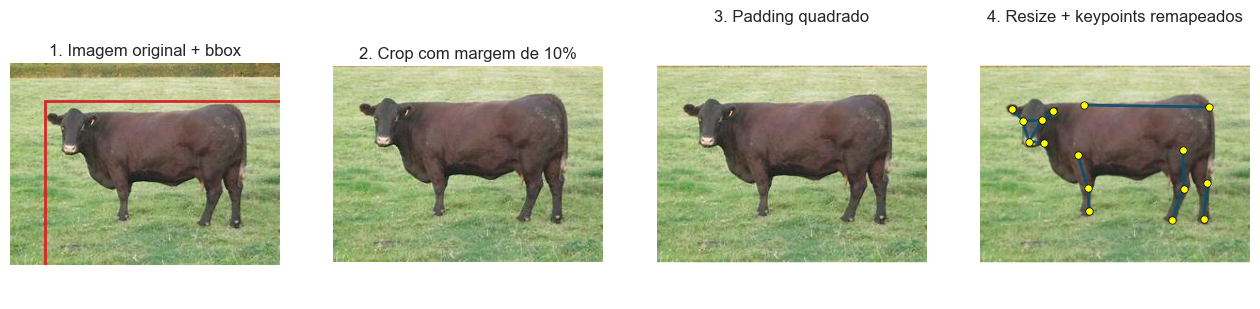

Imagem original: 300x225 pixels
Bounding box original: [39, 42, 265, 184]
Crop box aplicado: (13, 16, 300, 225)
Tamanho do crop: 287x209
Tamanho apos padding: 287x287
Resize final: 256x256
Nose remapeado: [45.491289198606275, 106.14634146341463, 1]
Tailbase remapeado: [216.75261324041813, 73.14285714285714, 1]


In [8]:
example_ann = next(ann for ann in cow_anns if images_map[int(ann['image_id'])] == EXAMPLE_FILENAME)
original_image = Image.open(COW_IMAGE_DIR / EXAMPLE_FILENAME).convert('RGB')
processed_example = preprocess_annotation(original_image, example_ann)

original_arr = np.array(original_image)
crop_arr = np.array(processed_example['crop'])
square_arr = np.array(processed_example['square'])
resized_arr = np.array(processed_example['resized'])

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))

axes[0].imshow(original_arr)
x, y, w, h = example_ann['bbox']
axes[0].add_patch(Rectangle((x, y), w, h, linewidth=2, edgecolor='#d62828', facecolor='none'))
axes[0].set_title('1. Imagem original + bbox')
axes[0].axis('off')

axes[1].imshow(crop_arr)
axes[1].set_title('2. Crop com margem de 10%')
axes[1].axis('off')

axes[2].imshow(square_arr)
axes[2].set_title('3. Padding quadrado')
axes[2].axis('off')

draw_pose(axes[3], resized_arr, processed_example['transformed_keypoints'], skeleton)
axes[3].set_title('4. Resize + keypoints remapeados')

save_current_figure(FIG_DIR / '08_step_by_step_example.png')

print(f'Imagem original: {original_image.width}x{original_image.height} pixels')
print(f'Bounding box original: {example_ann["bbox"]}')
print(f'Crop box aplicado: {processed_example["crop_box"]}')
print(f'Tamanho do crop: {processed_example["crop"].width}x{processed_example["crop"].height}')
print(f'Tamanho apos padding: {processed_example["square"].width}x{processed_example["square"].height}')
print(f'Resize final: {TARGET_SIZE}x{TARGET_SIZE}')
print(f'Nose remapeado: {processed_example["transformed_keypoints"][2]}')
print(f'Tailbase remapeado: {processed_example["transformed_keypoints"][-1]}')

## 3. Baseline de pose estimation para bovinos

Depois do pré-processamento, treinamos um baseline supervisionado para prever as coordenadas dos 20 keypoints bovinos a partir das imagens padronizadas em `256x256`.

### 3.1 Dataset para treinamento

O treinamento usa apenas o subconjunto bovino disponível localmente. A divisão entre treino e validação é determinística, com semente fixa, para manter a reprodutibilidade.

In [9]:
train_anns, val_anns = make_train_val_split(cow_anns, seed=SEED, val_ratio=0.20)
train_dataset = CowPoseDataset(train_anns, images_map, COW_IMAGE_DIR)
val_dataset = CowPoseDataset(val_anns, images_map, COW_IMAGE_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_pose_batch)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_pose_batch)

print(f'Amostras de treino: {len(train_anns)}')
print(f'Amostras de validacao: {len(val_anns)}')
print(f'Batch size: {BATCH_SIZE}')

Amostras de treino: 160
Amostras de validacao: 40
Batch size: 16


### 3.2 Modelo e configuração de treinamento

O modelo adotado é um **MobileNetV3-Small** com cabeça de regressão para `20 x 2` coordenadas normalizadas. Quando os pesos pré-treinados do ImageNet estão disponíveis, o notebook os utiliza e libera apenas o último bloco convolucional e a nova cabeça de saída.

In [10]:
pose_model, pretrained_loaded = load_pose_model(device)
optimizer = torch.optim.Adam([param for param in pose_model.parameters() if param.requires_grad], lr=LEARNING_RATE)

history = []
best_state_dict = copy.deepcopy(pose_model.state_dict())
best_val_loss = float('inf')
best_epoch = 0

print(f'Pesos pre-treinados carregados: {pretrained_loaded}')
print(f'Epochs planejadas: {EPOCHS}')
print(f'Taxa de aprendizado inicial: {LEARNING_RATE}')

for epoch in range(1, EPOCHS + 1):
    pose_model.train()
    train_losses = []

    for batch in train_loader:
        images = batch['image'].to(device)
        targets = batch['target'].to(device)
        visibility = batch['visibility'].to(device)

        optimizer.zero_grad()
        predictions = pose_model(images).view(-1, 20, 2)
        loss = masked_smooth_l1(predictions, targets, visibility)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    metrics = evaluate_pose_model(pose_model, val_loader, device)
    epoch_record = {
        'epoch': epoch,
        'train_loss': float(np.mean(train_losses)),
        'val_loss': metrics['loss'],
        'mae_pixels': metrics['mae_pixels'],
        'pck_005': metrics['pck_005'],
        'pck_010': metrics['pck_010'],
    }
    history.append(epoch_record)

    if metrics['loss'] < best_val_loss:
        best_val_loss = metrics['loss']
        best_epoch = epoch
        best_state_dict = copy.deepcopy(pose_model.state_dict())

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | train_loss={epoch_record['train_loss']:.4f} | "
        f"val_loss={epoch_record['val_loss']:.4f} | mae_px={epoch_record['mae_pixels']:.2f} | "
        f"PCK@0.05={epoch_record['pck_005']:.3f} | PCK@0.10={epoch_record['pck_010']:.3f}"
    )

pose_model.load_state_dict(best_state_dict)
final_metrics = evaluate_pose_model(pose_model, val_loader, device)
print(f'Melhor epoch: {best_epoch}')
print(f'Melhor val_loss: {best_val_loss:.4f}')

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /Users/lucasmagalhaes/Inteli/inteli-pose-estimation/.torch_cache/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100.0%


Pesos pre-treinados carregados: True
Epochs planejadas: 12
Taxa de aprendizado inicial: 0.001
Epoch 01/12 | train_loss=0.0207 | val_loss=0.0183 | mae_px=37.84 | PCK@0.05=0.030 | PCK@0.10=0.142
Epoch 02/12 | train_loss=0.0174 | val_loss=0.0175 | mae_px=34.43 | PCK@0.05=0.069 | PCK@0.10=0.228
Epoch 03/12 | train_loss=0.0165 | val_loss=0.0172 | mae_px=34.23 | PCK@0.05=0.070 | PCK@0.10=0.231
Epoch 04/12 | train_loss=0.0151 | val_loss=0.0172 | mae_px=34.08 | PCK@0.05=0.072 | PCK@0.10=0.211
Epoch 05/12 | train_loss=0.0145 | val_loss=0.0163 | mae_px=33.08 | PCK@0.05=0.080 | PCK@0.10=0.241
Epoch 06/12 | train_loss=0.0129 | val_loss=0.0226 | mae_px=35.65 | PCK@0.05=0.085 | PCK@0.10=0.298
Epoch 07/12 | train_loss=0.0122 | val_loss=0.0161 | mae_px=32.20 | PCK@0.05=0.070 | PCK@0.10=0.231
Epoch 08/12 | train_loss=0.0104 | val_loss=0.0182 | mae_px=32.49 | PCK@0.05=0.114 | PCK@0.10=0.270
Epoch 09/12 | train_loss=0.0081 | val_loss=0.0168 | mae_px=30.73 | PCK@0.05=0.097 | PCK@0.10=0.300
Epoch 10/12 | t

### 3.3 Curvas de treinamento

As curvas a seguir mostram a evolução da perda média de treino e validação ao longo das épocas. Elas ajudam a verificar se o baseline está aprendendo um padrão útil sem degradação brusca de generalização.

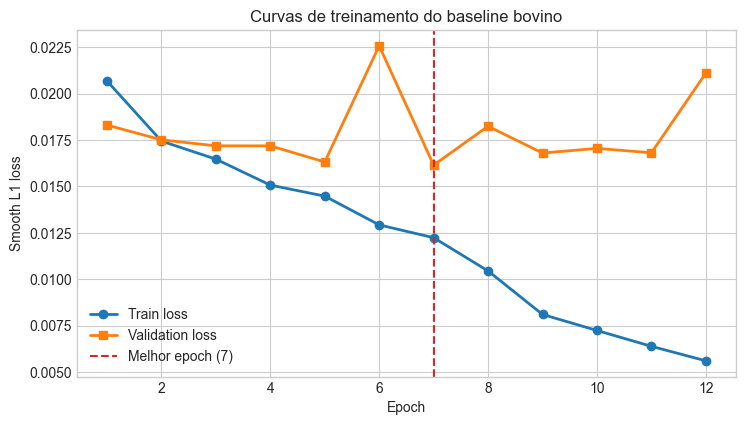

In [11]:
epochs = [row['epoch'] for row in history]
train_curve = [row['train_loss'] for row in history]
val_curve = [row['val_loss'] for row in history]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(epochs, train_curve, marker='o', linewidth=2, label='Train loss')
ax.plot(epochs, val_curve, marker='s', linewidth=2, label='Validation loss')
ax.axvline(best_epoch, color='#d62828', linestyle='--', linewidth=1.5, label=f'Melhor epoch ({best_epoch})')
ax.set_title('Curvas de treinamento do baseline bovino')
ax.set_xlabel('Epoch')
ax.set_ylabel('Smooth L1 loss')
ax.legend()
save_current_figure(FIG_DIR / '09_training_curves.png')

### 3.4 Resultados quantitativos

A avaliação quantitativa resume o erro médio das coordenadas previstas e a proporção de keypoints considerados corretos dentro de limiares espaciais mais rígidos (`PCK@0.05`) e mais tolerantes (`PCK@0.10`).

Resumo quantitativo do baseline:
- device: mps
- pretrained_backbone_loaded: True
- train_images: 160
- validation_images: 40
- visible_keypoints_in_validation: 597
- best_epoch: 7
- best_val_loss: 0.0161
- mae_normalized: 0.1258
- mae_pixels: 32.2
- pck_005: 0.07
- pck_010: 0.231


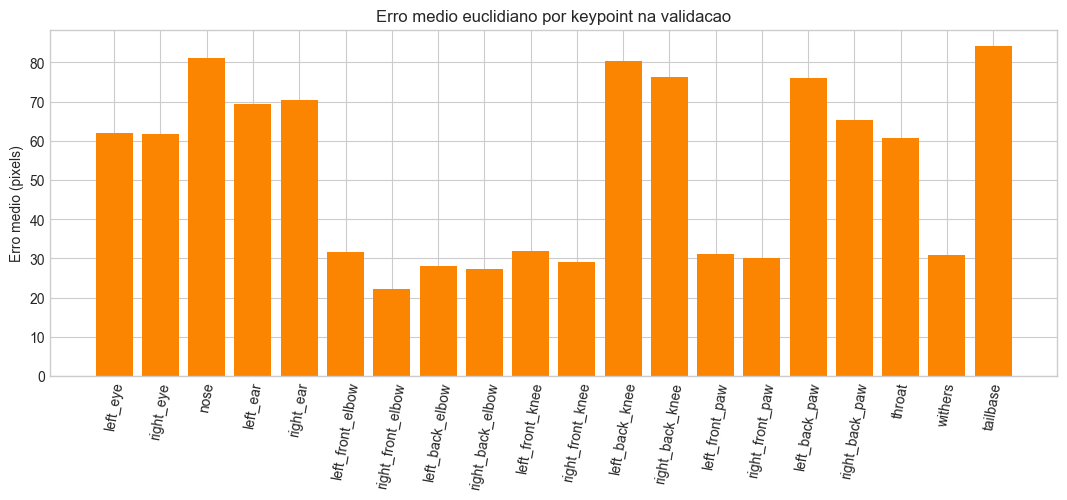

In [12]:
results_summary = {
    'device': str(device),
    'pretrained_backbone_loaded': pretrained_loaded,
    'train_images': len(train_anns),
    'validation_images': len(val_anns),
    'visible_keypoints_in_validation': final_metrics['visible_keypoints'],
    'best_epoch': best_epoch,
    'best_val_loss': round(best_val_loss, 4),
    'mae_normalized': round(final_metrics['mae_normalized'], 4),
    'mae_pixels': round(final_metrics['mae_pixels'], 2),
    'pck_005': round(final_metrics['pck_005'], 3),
    'pck_010': round(final_metrics['pck_010'], 3),
}

print('Resumo quantitativo do baseline:')
for key, value in results_summary.items():
    print(f'- {key}: {value}')

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(kp_names, final_metrics['per_keypoint_px_error'], color='#fb8500')
ax.set_title('Erro medio euclidiano por keypoint na validacao')
ax.set_ylabel('Erro medio (pixels)')
ax.tick_params(axis='x', rotation=80)
save_current_figure(FIG_DIR / '10_per_keypoint_error.png')

### 3.5 Exemplos qualitativos de predição

Além das métricas numéricas, vale observar como o modelo se comporta visualmente. Nos exemplos abaixo, o esqueleto de referência aparece em verde e a predição do baseline aparece em vermelho.

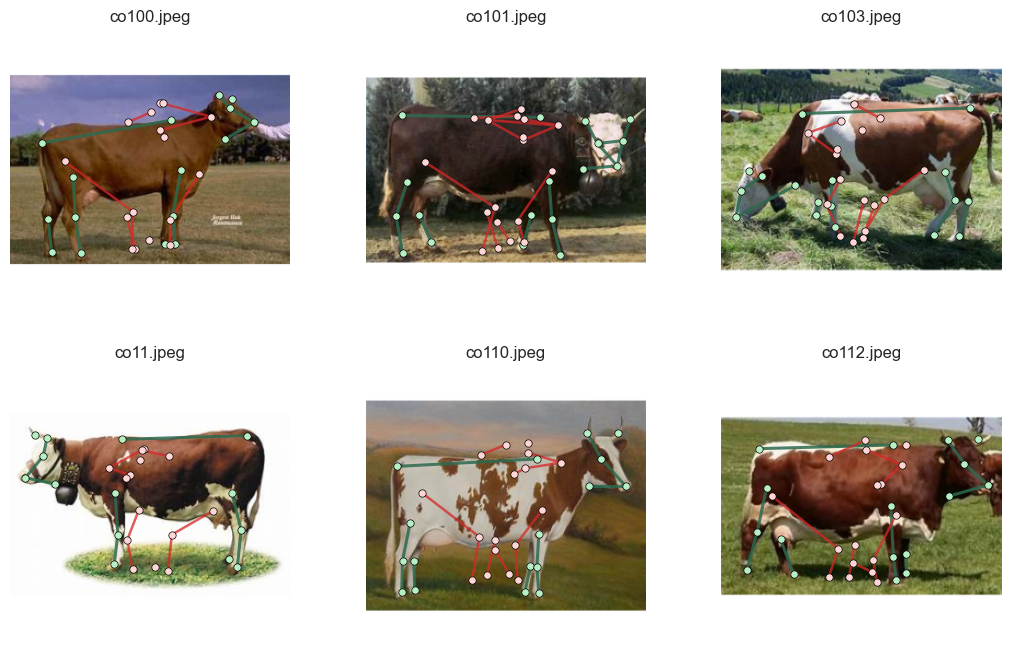

Keypoint com maior erro medio: tailbase (84.19 px)
Keypoint com menor erro medio: right_front_elbow (22.16 px)
JSON final para o README:
{
  "device": "mps",
  "pretrained_backbone_loaded": true,
  "train_images": 160,
  "validation_images": 40,
  "visible_keypoints_in_validation": 597,
  "best_epoch": 7,
  "best_val_loss": 0.0161,
  "mae_normalized": 0.1258,
  "mae_pixels": 32.2,
  "pck_005": 0.07,
  "pck_010": 0.231
}


In [13]:
prediction_examples = [predict_annotation(pose_model, ann, images_map, COW_IMAGE_DIR, device) for ann in val_anns[:6]]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, sample in zip(axes.flat, prediction_examples):
    ax.imshow(sample['image'])
    draw_pose(ax, sample['image'], sample['ground_truth_keypoints'], skeleton, point_color='#b7efc5', edge_color='#2d6a4f', edge_alpha=0.85, linewidth=2.2)
    draw_pose(ax, sample['image'], sample['predicted_keypoints'], skeleton, point_color='#ffd6d6', edge_color='#d62828', edge_alpha=0.75, linewidth=1.8)
    ax.set_title(sample['filename'])

save_current_figure(FIG_DIR / '11_prediction_examples.png')

hardest_keypoint_index = int(np.nanargmax(final_metrics['per_keypoint_px_error']))
easiest_keypoint_index = int(np.nanargmin(final_metrics['per_keypoint_px_error']))
print(f'Keypoint com maior erro medio: {kp_names[hardest_keypoint_index]} ({final_metrics["per_keypoint_px_error"][hardest_keypoint_index]:.2f} px)')
print(f'Keypoint com menor erro medio: {kp_names[easiest_keypoint_index]} ({final_metrics["per_keypoint_px_error"][easiest_keypoint_index]:.2f} px)')
print('JSON final para o README:')
print(json.dumps(results_summary, indent=2))

## 4. Conclusões finais

O experimento mostra que é possível adaptar o projeto para uma nova frente de **estimativa de pose bovina** com um pipeline relativamente simples: filtragem por classe, padronização espacial das imagens e um baseline supervisionado com transferência de aprendizado.

Os principais aprendizados desta implementação foram:

- a etapa de pré-processamento é decisiva para tornar o problema tratável, principalmente por causa da variação de enquadramento e oclusão;
- mesmo com apenas 200 imagens locais de bovinos, já é possível treinar um baseline e produzir métricas quantitativas e exemplos qualitativos;
- keypoints periféricos, como patas e articulações distais, tendem a apresentar erros maiores do que pontos centrais do tronco e da cabeça.

As principais limitações do trabalho são:

- o subconjunto local cobre apenas parte das imagens bovinas anotadas no JSON;
- o baseline usa regressão direta de coordenadas, que é uma abordagem mais simples do que métodos baseados em heatmaps;
- a avaliação ainda é limitada por um único split treino/validação.

Como trabalhos futuros, os passos mais promissores seriam ampliar o subconjunto de treino, aplicar data augmentation específico para keypoints, testar arquiteturas baseadas em heatmaps e comparar diferentes estratégias de fine-tuning e avaliação.